## Plot Wflow outputs

**HydroMT** provides a simple interface to model outputs from which we can make beautiful plots:

- Wflow gridded outputs are saved to the model `output_grid` component as a `xarray.Dataset`.
- Wflow netcdf scalar outputs are saved to the model `output_scalar` component as a `xarray.Dataset`.
- Wflow csv outputs are saved to the model `output_csv` component as a dict of `xarray.DataArray`.

These plots can be useful to analyze the model outputs or also compare model runs with different settings (different precipitation source or different parameters values).

### Load dependencies

In [31]:
import matplotlib.pyplot as plt
import hydromt
from hydromt_wflow import WflowSbmModel

### Read the model run(s) outputs

The **wflow_piave_subbasin** model was run using the default global data sources of the hydromt_wflow plugin. The different variables to save were set in a separate wflow configuration file: *wflow_sbm_results.toml*.

A second run of the model was also done, where the KsatHorFrac parameter of wflow was set to 10 (instead of the default 100 value) using an alternative configuration file: *wflow_sbm_results2.toml*.

We will use the below `runs` dictionnary to define the model run(s) we want to read and some settings for plotting. If you want to plot and compare several runs together, you can simply add them to the `runs` dictionnary.

In [32]:
# Dictionary listing the different wflow models and runs to compare, including plotting options
runs = {
    "run1": {
        "longname": "default",
        "color": "blue",
        "root": "wflow_piave_subbasin",
        "config_fn": "wflow_sbm_results.toml",
    },
    "run2": {
        "longname": "KsatHorFrac10",
        "color": "green",
        "root": "wflow_piave_subbasin",
        "config_fn": "wflow_sbm_results2.toml",
    },
}
mainrun = "run1"

In [33]:
# Initialize the different model run(s)
for r in runs:
    run = runs[r]
    model = WflowSbmModel(root=run["root"], mode="r+", config_filename=run["config_fn"])
    runs[r].update({"model": model})

2026-03-09 13:46:24,042 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 13:46:24,043 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 13:46:24,067 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 13:46:24,068 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_subbasin/wflow_sbm_results.toml.
2026-03-09 13:46:24,073 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 13:46:24,073 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_

Wflow can save different types of outputs (netcdf gridded output, netcdf scalar netcdf, csv scalar timeseries) that are also reflected in the organisation of the HydroMT-Wflow different `output` components:

* a **"output_grid" hydromt.RasterDataset** for the gridded netcdf file (output.netcdf_grid section of the TOML)
* a **"output_scalar" xarray.Dataset** for the netcdf point timeseries file (output.netcdf_scalar section of the TOML)
* different **hydromt.GeoDataArrays for the csv file** , one per column (output.csv section and csv.column sections of the TOML). The xy coordinates are the coordinates of the station or of the representative point of the subcatch/area. The variable name in the GeoDataArray corresponds to the csv header attribute or header_map when available.

Below you can see how to access to the different outputs of *run1* and its contents:

In [34]:
model1 = runs["run1"]["model"]
model1.output_grid.data

2026-03-09 13:46:24,107 - hydromt.hydromt_wflow.components.output_grid - output_grid - INFO - Read netcdf_grid output from C:\Data\TUD\MSc_CE\Courses\2nd_year\7.CIE5060_Thesis\Codes\MSc_thesis_hydromt_wflow\examples\wflow_piave_subbasin\run_results\output.nc


<xarray.Dataset> Size: 198kB
Dimensions:      (longitude: 58, latitude: 53, layer: 4, time: 8)
Coordinates:
  * longitude    (longitude) float64 464B 11.78 11.8 11.82 ... 12.7 12.72 12.73
  * latitude     (latitude) float64 424B 46.68 46.67 46.65 ... 45.85 45.83 45.82
  * layer        (layer) float64 32B 1.0 2.0 3.0 4.0
  * time         (time) datetime64[ns] 64B 2010-02-03 2010-02-04 ... 2010-02-10
    spatial_ref  int64 8B 0
Data variables:
    q_river      (time, latitude, longitude) float32 98kB dask.array<chunksize=(8, 53, 58), meta=np.ndarray>
    h_land       (time, latitude, longitude) float32 98kB dask.array<chunksize=(8, 53, 58), meta=np.ndarray>

In [35]:
model1.output_scalar.data

2026-03-09 13:46:25,374 - hydromt.hydromt_wflow.components.output_scalar - output_scalar - INFO - Read netcdf_scalar output from C:\Data\TUD\MSc_CE\Courses\2nd_year\7.CIE5060_Thesis\Codes\MSc_thesis_hydromt_wflow\examples\wflow_piave_subbasin\run_results\output_scalar.nc


<xarray.Dataset> Size: 212B
Dimensions:       (time: 8, Q_gauges: 1, temp_bycoord: 1, layer: 4)
Coordinates:
  * time          (time) datetime64[ns] 64B 2010-02-03 2010-02-04 ... 2010-02-10
  * Q_gauges      (Q_gauges) <U1 4B '1'
  * temp_bycoord  (temp_bycoord) <U12 48B 'temp_bycoord'
  * layer         (layer) float64 32B 1.0 2.0 3.0 4.0
Data variables:
    Q             (time, Q_gauges) float32 32B dask.array<chunksize=(8, 1), meta=np.ndarray>
    temp_coord    (time, temp_bycoord) float32 32B dask.array<chunksize=(8, 1), meta=np.ndarray>

In [36]:
import pandas as pd
import xarray as xr

# read the model output CSV
df_model = pd.read_csv("wflow_piave_subbasin/run_results/output.csv", index_col=0)

# convert time index
df_model.index = pd.to_datetime(df_model.index)

# select gauge columns
gauge_columns = [c for c in df_model.columns if c.startswith("Q_")]

# rename columns (remove 'Q_') for consistency
df_model.rename(columns={c: c.replace("Q_", "") for c in gauge_columns}, inplace=True)

# get the updated column names
gauge_columns = [c.replace("Q_", "") for c in gauge_columns]

# convert to xarray
da_model = xr.DataArray(
    df_model[gauge_columns].values,
    coords={"time": df_model.index, "index": gauge_columns},
    dims=("time", "index"),
    name="river_q_gauges_grdc",
)

In [37]:
model1.output_csv.data

TypeError: Cannot interpret 'Index(['2010-02-03T00:00:00', '2010-02-04T00:00:00', '2010-02-05T00:00:00',
       '2010-02-06T00:00:00', '2010-02-07T00:00:00', '2010-02-08T00:00:00',
       '2010-02-09T00:00:00', '2010-02-10T00:00:00'],
      dtype='str', name='time')' as a data type

### Read observations

You can also use HydroMT to read observations data in order to analyze your model results.
Here a **fictional** observations timeseries was prepared for the gauges_grdc locations. 

In [38]:
# Discharge data
timeseries_fn = "gauges_observed_flow.csv"  # observed discharge timeseries
name = "gauges_grdc"  # gauges locations in staticgeoms
stationID = "grdc_no"  # column name in staticgeoms containing the stations IDs

# Read the observations data
# read timeseries data and match with existing gdf
gdf = runs[mainrun]["model"].geoms.get(name)
gdf.index = gdf[stationID]
#da_ts = hydromt.readers.open_timeseries_from_table(timeseries_fn, name=name, sep=";")

import pandas as pd
import xarray as xr

# read with pandas
df = pd.read_csv(timeseries_fn, sep=";", index_col=0)

# convert time index properly
df.index = pd.to_datetime(df.index)

# FIX: remove "Q_" prefix and convert to int
df.columns = df.columns.str.replace("Q_", "").astype(int)

# convert to xarray
da_ts = xr.DataArray(
    df.values,
    coords={"time": df.index, "index": df.columns},
    dims=("time", "index"),
    name=name,
)

da = hydromt.vector.GeoDataArray.from_gdf(gdf, da_ts, index_dim="index")

obs = da
obs

<xarray.DataArray 'gauges_grdc' (index: 3, time: 8)> Size: 192B
array([[20.63727294, 26.21875575, 29.66606831, 32.1589512 , 32.26008825,
        31.09006663, 29.99882382, 29.10063939],
       [40.4367125 , 54.46918112, 59.2240498 , 59.21861451, 57.43010672,
        54.0491823 , 50.84542554, 48.09354881],
       [ 9.23746886, 11.94857033, 12.4642965 , 11.93064957, 11.23056571,
        10.51420303,  9.88308009,  9.31225629]])
Coordinates: (12/26)
  * index          (index) int32 12B 6349410 6349400 6349411
  * time           (time) datetime64[us] 64B 2010-02-03 ... 2010-02-10
    grdc_no        (index) int32 12B 6349410 6349400 6349411
    wmo_reg        (index) int32 12B 6 6 6
    sub_reg        (index) int32 12B 49 49 49
    river          (index) object 24B 'BOITE, TORRENTE' ... 'BOITE, TORRENTE'
    ...             ...
    t_yrs          (index) int32 12B 79 77 66
    lta_discharge  (index) float64 24B 9.461 10.36 2.256
    r_volume_yr    (index) float64 24B 0.2984 0.3268 0.07115
    r_height_yr    (index) float64 24B 953.2 915.5 867.6
    geometry       (index) object 24B POINT (12.216667 46.433333) ... POINT (...
    spatial_ref    int64 8B 0

### Plot model results

Here we plot the different model results for the gauges_grdc locations.

In [39]:
# Plotting options
# select the gauges_grdc results (name in csv column of wflow results to plot)
result_name = "river_q_gauges_grdc"

# selection of runs to plot (all or a subset)
runs_subset = ["run1", "run2"]

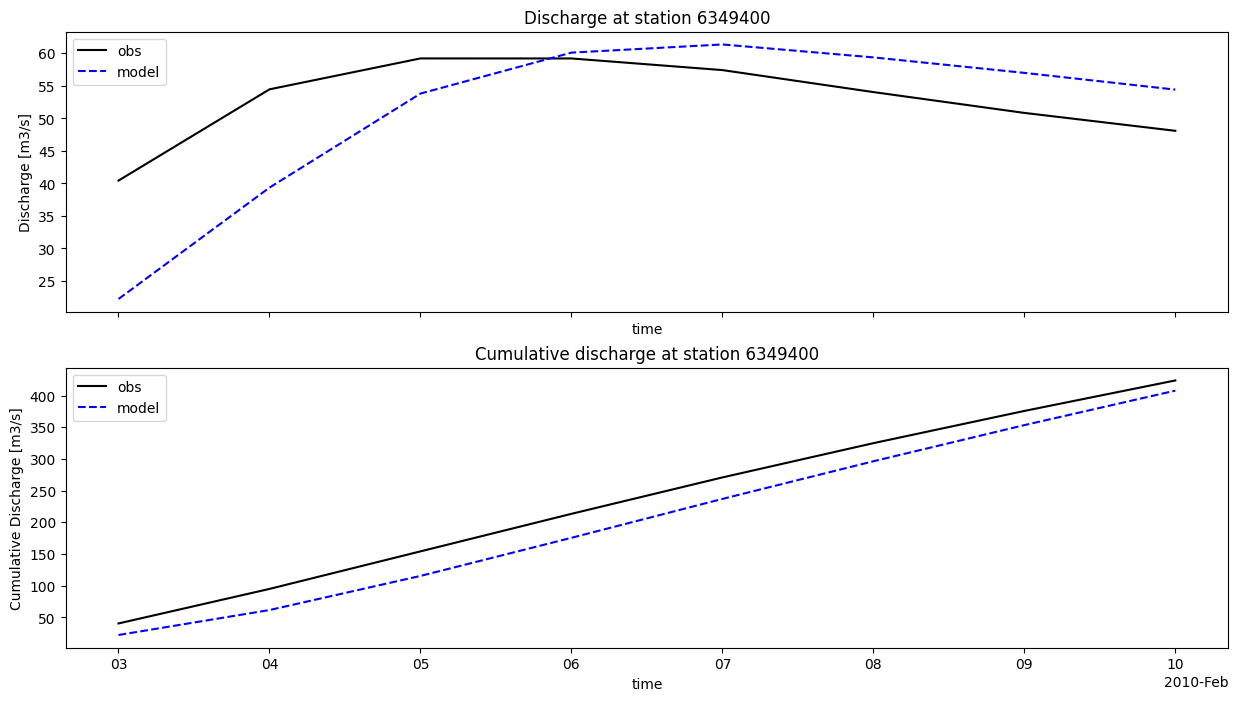

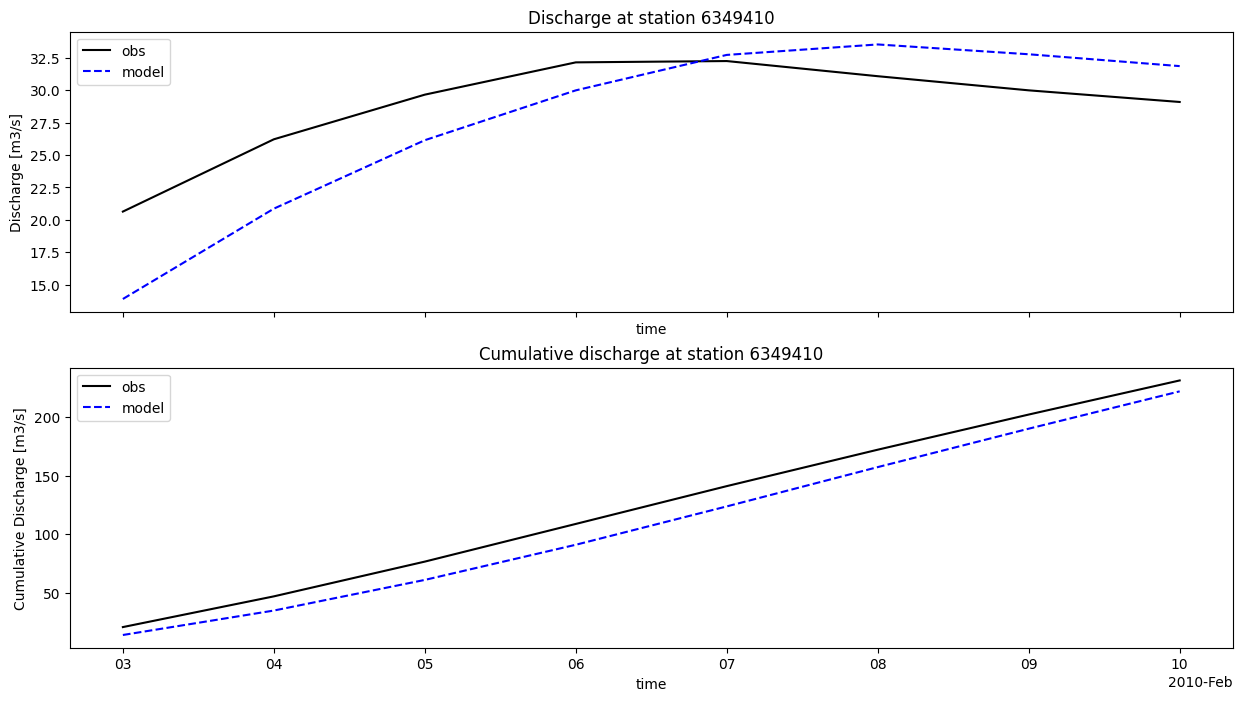

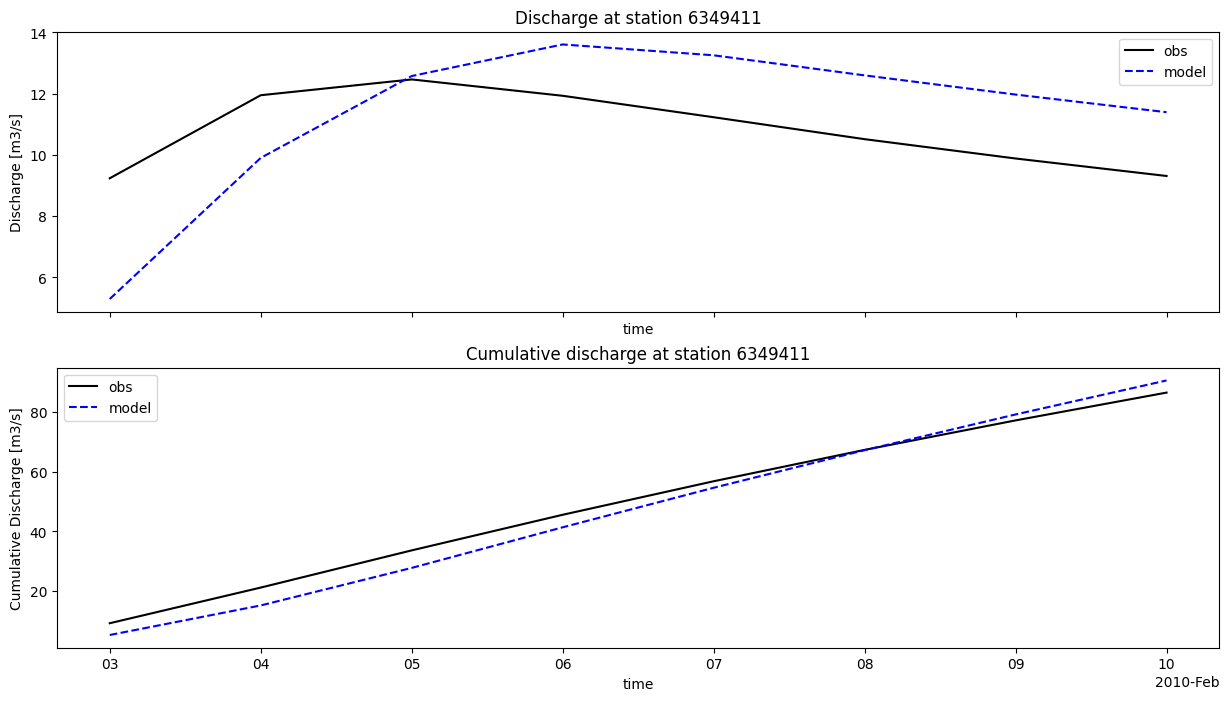

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from hydromt.stats import skills

# -----------------------------
# Observed discharge
# -----------------------------
df_obs = pd.read_csv("gauges_observed_flow.csv", sep=";", index_col=0)
df_obs.index = pd.to_datetime(df_obs.index)
df_obs.columns = df_obs.columns.str.replace("Q_", "").astype(int)

da_obs = xr.DataArray(
    df_obs.values,
    coords={"time": df_obs.index, "index": df_obs.columns},
    dims=("time", "index"),
)

# -----------------------------
# Modeled discharge (read manually)
# -----------------------------
df_model = pd.read_csv("wflow_piave_subbasin/run_results/output.csv", index_col=0)
df_model.index = pd.to_datetime(df_model.index)
gauge_columns = [c for c in df_model.columns if c.startswith("Q_")]
df_model[gauge_columns] = df_model[gauge_columns]
df_model.rename(columns={c: int(c.replace("Q_", "")) for c in gauge_columns}, inplace=True)

da_model = xr.DataArray(
    df_model[[int(c.replace("Q_", "")) for c in gauge_columns]].values,
    coords={"time": df_model.index, "index": [int(c.replace("Q_", "")) for c in gauge_columns]},
    dims=("time", "index"),
)

# -----------------------------
# Plotting
# -----------------------------
station_ids = sorted(list(set(da_obs.index.values) & set(da_model.index.values)))

for st in station_ids:
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(15, 8))

    # Observed
    obs_i = da_obs.sel(index=st)
    obs_i.plot.line(ax=axes[0], color="black", label="obs")

    # Modeled
    run_i = da_model.sel(index=st)
    run_i.plot.line(ax=axes[0], color="blue", linestyle="--", label="model")

    axes[0].set_ylabel("Discharge [m3/s]")
    axes[0].set_title(f"Discharge at station {st}")
    axes[0].legend()

    # Cumulative
    obs_i.cumsum().plot.line(ax=axes[1], color="black", label="obs")
    run_i.cumsum().plot.line(ax=axes[1], color="blue", linestyle="--", label="model")
    axes[1].set_ylabel("Cumulative Discharge [m3/s]")
    axes[1].set_title(f"Cumulative discharge at station {st}")
    axes[1].legend()

You can see on the discharge plots legends that some statistical criteria were computed using the fictional observations and the model runs outputs.

These statistics were computed using the **stats** module of HydroMT. You can find the available statisctics functions in the [documentation](https://deltares.github.io/hydromt/latest/api/stats.html#statistics-and-performance-metrics).

And finally once the `outputs` are loaded, you can use them to derive more statistics or plots to further analyze your model.